# Network Intrusion Detection Sytem - Training V5 (Cross-Dataset Domain Adaptation)

## Objective
This notebook implements a **Cross-Dataset Training Strategy** with **Domain Adaptation**.

**Strategy Evaluation:**
Training purely on one dataset (Source: CICDDoS2019) and testing on another (Target: CICIDS2017) often fails due to distribution shifts (different network baselines, different attack tools). 
To address this, we use a **Few-Shot Domain Adaptation** approach:
1.  **Source Data**: **CICDDoS2019** (High volume, modern DDoS attacks).
2.  **Target Injection**: We mix in a small sample (**3%**) of **CICIDS2017** (both Attack and Benign samples) into the training set.
3.  **Test Data**: The model is evaluated on the **remaining 97% of CICIDS2017**.

**Benefits:**
- **Robustness:** The model learns generic attack patterns from 2019 but adapts to the specific traffic characteristics of the 2017 environment.
- **Realism:** Simulates a scenario where a general model is deployed to a new network with only a small amount of labeled local data available for tuning.

## Pipeline Steps
1.  **Data Loading**: Load both CICDDoS2019 and CICIDS2017.
2.  **Preprocessing & Mixing**: Construct `train_mix` (2019 + 3% of 2017) and `test_set` (97% of 2017).
3.  **Feature Selection**: Select top features using `train_mix`.
4.  **Model Training**: Retrain XGBoost on `train_mix` (reduced features).
5.  **Calibration & Optimization**: Calibrate probabilities and find the optimal threshold using a validation split of `train_mix` (optimizing on "known" data).
6.  **Final Evaluation**: Test the optimized model on the unseen `test_set` (2017).
7.  **Artifact Export**: Save model and config.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import sys
import os

# Ensure local modules can be imported
sys.path.append(os.getcwd())
from calibration_utils import calibrate_and_optimize

## 1. Load Data
We load both the 2019 (Source) and 2017 (Target) datasets.

In [10]:
PATH_2019 = "data/cicddos2019_binary_processed.csv"
PATH_2017 = "data/cicids2017_binary_processed.csv"

print(f"Loading CICDDoS2019 from {PATH_2019}...")
df_2019 = pd.read_csv(PATH_2019)

print(f"Loading CICIDS2017 from {PATH_2017}...")
df_2017 = pd.read_csv(PATH_2017)

# Clean Data (Inf/NaN)
def clean_df(df):
    return df.replace([np.inf, -np.inf], np.nan).dropna()

df_2019 = clean_df(df_2019)
df_2017 = clean_df(df_2017)

print(f"Cleaned 2019 Shape: {df_2019.shape}")
print(f"Cleaned 2017 Shape: {df_2017.shape}")

Loading CICDDoS2019 from data/cicddos2019_binary_processed.csv...
Loading CICIDS2017 from data/cicids2017_binary_processed.csv...
Cleaned 2019 Shape: (418913, 74)
Cleaned 2017 Shape: (223112, 74)


## 1.1 Feature Engineering
We add derived features to both datasets to capture flow dynamics better.
- **Packet/Byte Rates**: Traffic intensity.
- **Ratios**: Relationship between forward and backward traffic.
- **Log Transforms**: To handle skewed distributions.

In [11]:
def first_existing_series(df, candidates):
    """Return first Series in df among candidates list, or None if none present."""
    for c in candidates:
        if c in df.columns:
            return df[c]
    return None

def add_derived_features(df):
    df = df.copy()
    # convert numeric-like object cols to numeric where possible
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = pd.to_numeric(df[c], errors='ignore')

    # ensure forward/backward packet counts exist (create if not present)
    if 'total_fwd_packets' not in df.columns:
        df['total_fwd_packets'] = 0
    if 'total_backward_packets' not in df.columns:
        # some datasets use 'total_backward_packets' naming variants
        if 'total_backwards_packets' in df.columns:  # example typo fallback (if any)
            df['total_backward_packets'] = df['total_backwards_packets']
        else:
            df['total_backward_packets'] = 0

    # total packets
    df['total_packets'] = df['total_fwd_packets'].fillna(0) + df['total_backward_packets'].fillna(0)

    # total bytes: pick first existing column among common candidates
    fwd_candidates = ['fwd_packets_length_total', 'total_length_of_fwd_packets', 'subflow_fwd_bytes', 'Subflow Fwd Bytes', 'subflow_fwd_bytes']
    bwd_candidates = ['bwd_packets_length_total', 'total_length_of_bwd_packets', 'subflow_bwd_bytes', 'Subflow Bwd Bytes', 'subflow_bwd_bytes']

    fwd_bytes_series = first_existing_series(df, fwd_candidates)
    bwd_bytes_series = first_existing_series(df, bwd_candidates)

    if fwd_bytes_series is not None:
        df['total_fwd_bytes'] = fwd_bytes_series.fillna(0)
    else:
        df['total_fwd_bytes'] = 0

    if bwd_bytes_series is not None:
        df['total_bwd_bytes'] = bwd_bytes_series.fillna(0)
    else:
        df['total_bwd_bytes'] = 0

    df['total_bytes'] = df['total_fwd_bytes'] + df['total_bwd_bytes']

    # duration safe (ensure numeric and positive + tiny epsilon)
    if 'flow_duration' in df.columns:
        df['flow_duration'] = pd.to_numeric(df['flow_duration'], errors='coerce').fillna(0).clip(lower=0) + 1e-6
    else:
        df['flow_duration'] = 1.0

    # derived features (guards for zero division)
    df['packet_rate'] = df['total_packets'] / df['flow_duration']
    df['byte_rate'] = df['total_bytes'] / df['flow_duration']
    df['mean_packet_size'] = (df['total_bytes'] / df['total_packets'].replace({0: np.nan})).fillna(0)
    df['fwd_ratio'] = (df['total_fwd_packets'] / df['total_packets'].replace({0: np.nan})).fillna(0)

    # iat_range if columns exist (safe)
    if 'flow_iat_max' in df.columns and 'flow_iat_min' in df.columns:
        df['iat_range'] = (pd.to_numeric(df['flow_iat_max'], errors='coerce').fillna(0) -
                           pd.to_numeric(df['flow_iat_min'], errors='coerce').fillna(0)).clip(lower=0)
    else:
        df['iat_range'] = 0.0

    # log transforms (handle negatives/NaNs by log1p on non-negative)
    df['log_packet_rate'] = np.log1p(df['packet_rate'].clip(lower=0))
    df['log_byte_rate'] = np.log1p(df['byte_rate'].clip(lower=0))
    df['log_total_bytes'] = np.log1p(df['total_bytes'].clip(lower=0))
    df['log_total_packets'] = np.log1p(df['total_packets'].clip(lower=0))

    return df

print("Applying feature engineering...")
df_2019 = add_derived_features(df_2019)
df_2017 = add_derived_features(df_2017)

print(f"New 2019 Shape: {df_2019.shape}")
print(f"New 2017 Shape: {df_2017.shape}")

Applying feature engineering...
New 2019 Shape: (418913, 87)
New 2017 Shape: (223112, 87)


## 2. Preprocessing & Dataset Mixing (Domain Adaptation)
We split CICIDS2017 into two parts:
- **Sample (3%)**: To be mixed into training data.
- **Test (97%)**: To be kept strictly for final evaluation.

We stratify the split to ensure we get both Attack and Benign examples in the sample.

In [12]:
# Split 2017 into Sample (3%) and Test (97%)
df_2017_test, df_2017_sample = train_test_split(
    df_2017, 
    test_size=0.03, 
    stratify=df_2017['label'], 
    random_state=42
)

print(f"2017 Sample Size (for training): {df_2017_sample.shape}")
print(f"2017 Test Size (for eval): {df_2017_test.shape}")

# Create Training Mix: All of 2019 + 3% of 2017
df_train_mix = pd.concat([df_2019, df_2017_sample], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal Training Mix Shape: {df_train_mix.shape}")
print("Training Mix Label Dist:")
print(df_train_mix['label'].value_counts(normalize=True))

# Prepare X/y arrays
X_train_mix = df_train_mix.drop(columns=['label'])
y_train_mix = df_train_mix['label'].astype(int)

X_test_final = df_2017_test.drop(columns=['label'])
y_test_final = df_2017_test['label'].astype(int)

2017 Sample Size (for training): (6694, 87)
2017 Test Size (for eval): (216418, 87)

Final Training Mix Shape: (425607, 87)
Training Mix Label Dist:
label
1    0.770781
0    0.229219
Name: proportion, dtype: float64


## 3. Feature Selection
We run feature selection on `df_train_mix` to find features that are predictive across this combined domain.

Training initial model for feature selection on Mix...

Top 30 Features Selected:
['packet_length_min', 'flow_iat_mean', 'idle_std', 'ack_flag_count', 'fwd_packet_length_max', 'fwd_iat_min', 'total_fwd_packets', 'bwd_header_length', 'bwd_packet_length_std', 'bwd_packetss', 'total_packets', 'packet_length_std', 'fwd_packetss', 'urg_flag_count', 'total_bytes', 'bwd_packet_length_max', 'fwd_iat_std', 'iat_range', 'packet_length_max', 'bwd_iat_max', 'avg_packet_size', 'fwd_packet_length_min', 'fwd_header_length', 'fwd_iat_max', 'bwd_packet_length_min', 'fwd_act_data_packets', 'active_min', 'bwd_packets_length_total', 'active_max', 'flow_iat_max']


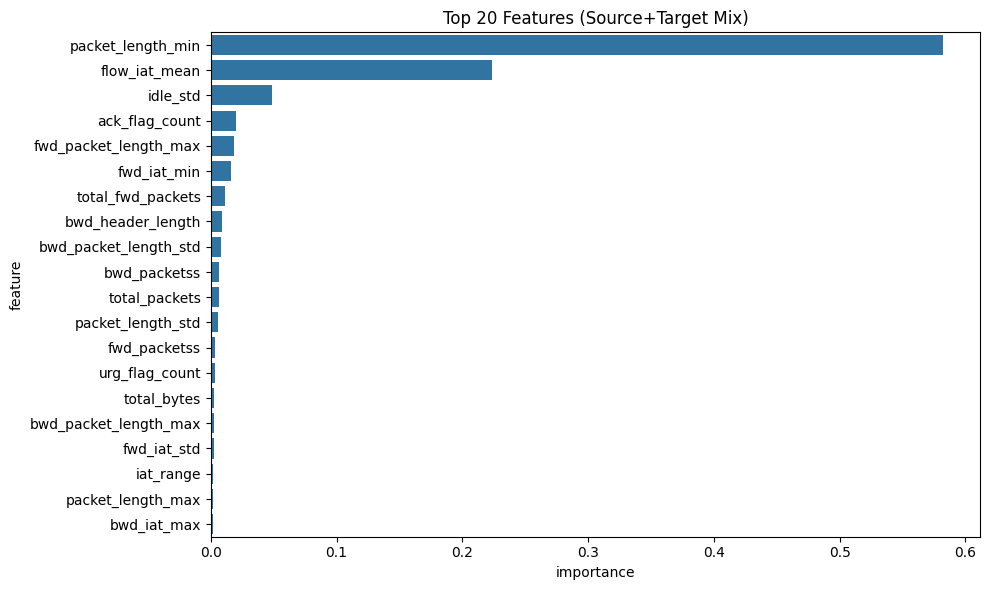

In [13]:
scale_pos_weight = y_train_mix.value_counts()[0] / y_train_mix.value_counts()[1]

print("Training initial model for feature selection on Mix...")
model_initial = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)
model_initial.fit(X_train_mix, y_train_mix)

# Get Importances
importances = model_initial.feature_importances_
feature_names = X_train_mix.columns
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

# Select Top 30
TOP_K = 30
selected_features = feat_imp['feature'].head(TOP_K).tolist()

print(f"\nTop {TOP_K} Features Selected:")
print(selected_features)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(20))
plt.title("Top 20 Features (Source+Target Mix)")
plt.tight_layout()
plt.show()

## 4. Retrain on Reduced Feature Set
We now retrain the model on the `train_mix` using only the top 30 features.
We split `train_mix` internally to have a validation set for **Early Stopping**.

In [14]:
# Filter features
X_train_mix_red = X_train_mix[selected_features]
X_test_final_red = X_test_final[selected_features]

# Internal split for Training vs Internal Validation (for early stopping & calibration)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_mix_red, y_train_mix, 
    test_size=0.15, 
    stratify=y_train_mix, 
    random_state=42
)

print(f"Training Subset: {X_tr.shape}")
print(f"Internal Validation Subset: {X_val.shape}")

print("Retraining reduced model...")
model_red = XGBClassifier(
    n_estimators=10000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    n_jobs=-1,
    random_state=42,
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=100
)

model_red.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

Training Subset: (361765, 30)
Internal Validation Subset: (63842, 30)
Retraining reduced model...
[0]	validation_0-auc:0.99825
[100]	validation_0-auc:0.99993
[200]	validation_0-auc:0.99997
[300]	validation_0-auc:0.99998
[400]	validation_0-auc:0.99998
[500]	validation_0-auc:0.99998
[600]	validation_0-auc:0.99998
[700]	validation_0-auc:0.99998
[800]	validation_0-auc:0.99998
[825]	validation_0-auc:0.99998


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## 5. Calibration & Optimization (On Training Mix)
As requested, we perform **Threshold Optimization** and **Calibration** using the training set (specifically the internal validation split `X_val`, `y_val`). 
This ensures the threshold is tuned to the *known* distribution (Mix of 2019 + 3% 2017) to minimize False Positives.

In [15]:
# We use X_tr for calibration fitting (CV) and X_val for threshold finding
# This ensures we don't overfit the threshold to the data the model saw during training
calib_model, best_threshold = calibrate_and_optimize(
    model=model_red,
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_val,  # <--- Optimizing on the Internal Validation set (part of train_mix)
    y_test=y_val,
    features=selected_features,
    output_dir="model_outputs_v5"
)

=== CALIBRATION ===
Calibrating model using Sigmoid calibration (3-fold CV)...
Generating calibrated probabilities for Test set...

=== THRESHOLD OPTIMIZATION ===
Searching for optimal threshold to minimize False Positives...
Threshold  | FP Rate         | FN Rate         | F1-Score  
------------------------------------------------------------
0.50       | 0.0012          | 0.0017          | 0.9990
0.51       | 0.0012          | 0.0017          | 0.9990
0.52       | 0.0012          | 0.0017          | 0.9990
0.53       | 0.0010          | 0.0017          | 0.9990
0.54       | 0.0010          | 0.0017          | 0.9990
0.55       | 0.0010          | 0.0017          | 0.9990
0.56       | 0.0010          | 0.0017          | 0.9990
0.57       | 0.0010          | 0.0017          | 0.9990
0.58       | 0.0010          | 0.0017          | 0.9990
0.59       | 0.0010          | 0.0017          | 0.9990
0.60       | 0.0010          | 0.0017          | 0.9990
0.61       | 0.0010          | 0.0017

## 6. Final Evaluation (On 2017 Test Set)
Now we test the finalized, calibrated, and threshold-optimized model on the **97% of CICIDS2017** that it has never seen.
This determines the true robustness of the cross-dataset strategy.

⚔️ FINAL TEST on CICIDS2017 (Remaining 97% - 216418 samples)
Applying Optimized Threshold: 0.9700
              precision    recall  f1-score   support

           0     0.9968    0.9958    0.9963     92243
           1     0.9969    0.9977    0.9973    124175

    accuracy                         0.9969    216418
   macro avg     0.9969    0.9967    0.9968    216418
weighted avg     0.9969    0.9969    0.9969    216418

ROC AUC: 0.99989


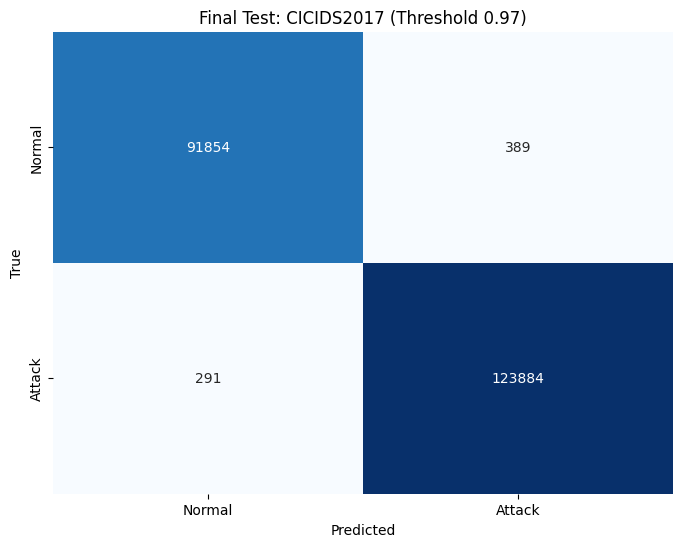

In [16]:
print("="*60)
print(f"⚔️ FINAL TEST on CICIDS2017 (Remaining 97% - {X_test_final_red.shape[0]} samples)")
print("="*60)

# 1. Predict Proba
y_prob_final = calib_model.predict_proba(X_test_final_red)[:, 1]

# 2. Apply Optimized Threshold
print(f"Applying Optimized Threshold: {best_threshold:.4f}")
y_pred_final = (y_prob_final >= best_threshold).astype(int)

# 3. Metrics
print(classification_report(y_test_final, y_pred_final, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test_final, y_prob_final):.5f}")

# 4. Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title(f"Final Test: CICIDS2017 (Threshold {best_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 6. Comprehensive Reporting Visualizations
The following plots are generated to analyze the model's performance and behavior in detail. These are suitable for inclusion in the technical report.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Set Style
sns.set_style("whitegrid")


### 6.1 Exploratory Data Analysis (EDA)
Comparing Class Distributions across Source (2019), Target (2017), and the Training Mix.

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
df_2019['label'].value_counts().sort_index().plot(kind='bar', color=['#3498db', '#e74c3c'], alpha=0.8)
plt.title("Source Domain (2019)\n(Imbalanced)")
plt.xlabel("Label (0=Benign, 1=Attack)")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
df_2017['label'].value_counts().sort_index().plot(kind='bar', color=['#3498db', '#e74c3c'], alpha=0.8)
plt.title("Target Domain (2017)\n(Test Set)")
plt.xlabel("Label")

plt.subplot(1, 3, 3)
df_train_mix['label'].value_counts().sort_index().plot(kind='bar', color=['#3498db', '#e74c3c'], alpha=0.8)
plt.title("Training Mix (Domain Adapted)\n(Source + 3% Target)")
plt.xlabel("Label")

plt.tight_layout()
plt.show()

### 6.2 ROC and Precision-Recall Curves
Evaluating the trade-off between True Positive Rate / False Positive Rate and Precision / Recall.

In [ ]:
fpr, tpr, _ = roc_curve(y_test_final, y_prob_final)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_final, y_prob_final)
pr_auc = auc(recall, precision)

plt.figure(figsize=(14, 6))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'Model (AUC = {roc_auc:.4f})', color='dodgerblue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance')
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# PR Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'Model (AP = {pr_auc:.4f})', color='forestgreen', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Threshold Tuning Curve
Analyzing how F1-Score changes with the decision threshold to verify our optimal selection.

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test_final, y_prob_final)
# Compute F1 for each threshold (F1 = 2*P*R/(P+R))
numerator = 2 * precisions * recalls
denominator = precisions + recalls
f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", alpha=0.5)
plt.plot(thresholds, recalls[:-1], "g--", label="Recall", alpha=0.5)
plt.plot(thresholds, f1_scores[:-1], "r-", label="F1 Score", linewidth=2)

# Mark Best Threshold
plt.axvline(best_threshold, color='black', linestyle=':', label=f"Selected Threshold ({best_threshold:.3f})")
plt.axhline(max(f1_scores), color='gray', linestyle=':', alpha=0.5)

plt.title("F1-Score vs Decision Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend(loc="lower left")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)
plt.show()

### 6.4 Prediction Probability Distribution
Visualizing the separation between Normal and Attack traffic predictions. A good model should have little overlap.

In [ ]:
plt.figure(figsize=(12, 6))

# Plot Histograms
sns.histplot(y_prob_final[y_test_final==0], color='blue', label='True Normal', bins=100, alpha=0.5, stat='density', kde=True)
sns.histplot(y_prob_final[y_test_final==1], color='red', label='True Attack', bins=100, alpha=0.5, stat='density', kde=True)

plt.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label=f'Decision Boundary ({best_threshold:.3f})')

plt.title("Model Confidence Distribution (Log Scale)")
plt.xlabel("Predicted Probability (0 = Normal, 1 = Attack)")
plt.ylabel("Density (Log Scale)")
plt.yscale('log') # Log scale to see the outliers/overlap better
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6.5 Enhanced Confusion Matrix
Standard Confusion Matrix with normalization to see recall/precision rates visually.

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test_final, y_pred_final)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Attack'],
            yticklabels=['True: Normal', 'True: Attack'])
plt.title("Confusion Matrix (Counts)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens", cbar=False,
            xticklabels=['Pred: Normal', 'Pred: Attack'],
            yticklabels=['True: Normal', 'True: Attack'])
plt.title("Confusion Matrix (Normalized by True Class)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()